# Forecastability analysis

This dataset-level notebook separates forecastability diagnostics from model evaluation. It covers every series used by the point and probabilistic forecasting exercises without using validation or test outcomes:

- each of the five registered macroeconomic series is reported separately, using its training partition;
- the S&P 500 log-return series and the two long conformal synthetic series use only their model-selection training partitions;
- each global synthetic process is summarized across all 100 component series, using the first 480 observations of each series;

Residual variability (RV) is computed only on the original scale from decomposition residuals when the target mean is materially different from zero. It is not reported for AutoStationary rows because a transformed-scale standard deviation divided by an original-scale mean is not dimensionally coherent. Standard deviation (SD) is retained for centered processes, for which RV is ill-conditioned. Residual spectral entropy (RSE) is computed directly for targets already treated as stationary, and after AutoStationary where detrending or deseasonalization is required.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'thesis').exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from thesis.data_preparation import (
    MANUAL_DATASETS,
    create_train_val_test_splits,
    load_dataset,
)
from thesis.global_evaluation import (
    GLOBAL_SYNTHETIC_DATASETS,
    load_global_panel,
    split_global_panel,
)
from thesis.probabilistic_evaluation import (
    load_sp500_returns,
    split_sp500_stages,
)
from src.transformations import (
    apply_stationarity_transform,
    compute_forecastability_analysis,
    spectral_entropy,
)
from thesis.reporting import (
    IMAGES_DIR,
    publication_latex,
    save_matplotlib_figure,
)

METRICS_DIR = REPO_ROOT / 'thesis' / 'metrics'
RESULTS_DIR = REPO_ROOT / 'thesis' / 'results'
FIGURE_DIR = IMAGES_DIR / 'forecastability_analysis'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'

## Leakage-safe analysis sample

Forecastability is treated as a descriptive property of the fitting data. Consequently, changing a forecasting notebook from validation to test cannot change these diagnostics. Macroeconomic datasets use `ts_train`; the probabilistic series use their initial model-selection training partitions; and global panels use their aligned 480-step training partition.

In [2]:
analysis_data = {}
audit_rows = []
table_labels = {
    'emae': 'EMAE (Argentina)',
    'ecai_us': 'ECAI (US)',
    'unemployment_us': 'Unemployment rate (US)',
    'real_gdp_argentina': 'Real GDP (Argentina)',
    'real_gdp_us': 'Real GDP (US)',
    'sp500_returns': 'S&P 500 log returns',
    'conformal_ar1': 'Conformal AR(1)',
    'conformal_sinusoid': 'Conformal sinusoid',
    'global_autoregressive': 'AR(1)',
    'global_pseudo_periodic': 'Pseudo-periodic',
    'global_sinusoidal_trend_noise': 'Sinusoid + trend + noise',
}

for dataset_name, registered_config in MANUAL_DATASETS.items():
    raw, config = load_dataset(dataset_name, 'manual')
    ts_train, ts_val, ts_test, id_col, time_col, target_col = (
        create_train_val_test_splits(raw, config, 'manual')
    )
    seasonality = int(config.get('seasonality', 1))
    metric_config = {
        **config,
        'table_label': table_labels[dataset_name],
        'seasonality': seasonality if seasonality > 1 else None,
    }
    analysis_data[dataset_name] = {
        'config': metric_config,
        'type': 'manual',
        'id_col': id_col,
        'time_col': time_col,
        'target_col': target_col,
        'freq': config['freq'],
        'ts_train': ts_train.copy(),
        'fit_df': ts_train.copy(),
        'pred_df': ts_train.copy(),
    }
    audit_rows.append({
        'Dataset': dataset_name,
        'Label': metric_config['table_label'],
        'Scope': 'Individual',
        'Series': ts_train[id_col].nunique(),
        'Training observations per series': int(ts_train.groupby(id_col).size().iloc[0]),
        'First training observation': ts_train[time_col].min(),
        'Last training observation': ts_train[time_col].max(),
    })

sp500 = load_sp500_returns(REPO_ROOT / 'thesis' / 'data' / 'sp500_daily.csv')
sp500_train = split_sp500_stages(sp500)['train'].copy()
sp500_train['analysis_time'] = (
    pd.Timestamp('2000-01-01') + pd.to_timedelta(sp500_train['ds'], unit='D')
)
analysis_data['sp500_returns'] = {
    'config': {
        'label': table_labels['sp500_returns'],
        'table_label': table_labels['sp500_returns'],
        'seasonality': 5,
    },
    'type': 'individual',
    'id_col': 'unique_id',
    'time_col': 'analysis_time',
    'target_col': 'y',
    'freq': 'D',
    'ts_train': sp500_train.copy(),
    'fit_df': sp500_train.copy(),
    'pred_df': sp500_train.copy(),
}
audit_rows.append({
    'Dataset': 'sp500_returns',
    'Label': table_labels['sp500_returns'],
    'Scope': 'Individual',
    'Series': 1,
    'Training observations per series': len(sp500_train),
    'First training observation': sp500_train['date'].min(),
    'Last training observation': sp500_train['date'].max(),
})

conformal_specs = {
    'conformal_ar1': {
        'path': REPO_ROOT / 'thesis' / 'data' / 'synthetic_ar1_conformal.csv',
        'series_id': 'AR1_CONFORMAL',
        'seasonality': None,
    },
    'conformal_sinusoid': {
        'path': REPO_ROOT / 'thesis' / 'data' / 'synthetic_sinusoidal_conformal.csv',
        'series_id': 'SINUSOIDAL_CONFORMAL',
        'seasonality': 20,
    },
}
for analysis_key, spec in conformal_specs.items():
    if spec['path'].exists():
        raw = pd.read_csv(spec['path'])
    elif analysis_key == 'conformal_sinusoid':
        # The process is deterministic, so this fallback is exactly the
        # documented file produced by synthethic_ts_generation.ipynb.
        steps = np.arange(6000, dtype=int)
        signal_time = np.linspace(0, 1200, 6000)
        raw = pd.DataFrame({
            'time': steps,
            'signal_time': signal_time,
            'value': np.sin(2 * np.pi * 0.25 * signal_time),
        })
        print('Conformal sinusoid CSV is absent; reconstructed its exact deterministic DGP.')
    else:
        raise FileNotFoundError(
            f"Missing {spec['path']}; run the long conformal generator cell first."
        )
    raw = raw.sort_values('time').query('time < 4000').copy()
    conformal_train = pd.DataFrame({
        'unique_id': spec['series_id'],
        'analysis_time': pd.Timestamp('2000-01-01') + pd.to_timedelta(
            raw['time'].astype(int), unit='D'
        ),
        'y': pd.to_numeric(raw['value'], errors='raise'),
    })
    analysis_data[analysis_key] = {
        'config': {
            'label': table_labels[analysis_key],
            'table_label': table_labels[analysis_key],
            'seasonality': spec['seasonality'],
        },
        'type': 'individual',
        'id_col': 'unique_id',
        'time_col': 'analysis_time',
        'target_col': 'y',
        'freq': 'D',
        'ts_train': conformal_train.copy(),
        'fit_df': conformal_train.copy(),
        'pred_df': conformal_train.copy(),
    }
    audit_rows.append({
        'Dataset': analysis_key,
        'Label': table_labels[analysis_key],
        'Scope': 'Individual',
        'Series': 1,
        'Training observations per series': len(conformal_train),
        'First training observation': int(raw['time'].min()),
        'Last training observation': int(raw['time'].max()),
    })

for dataset_name, registered_config in GLOBAL_SYNTHETIC_DATASETS.items():
    panel, config = load_global_panel(dataset_name)
    ts_train = split_global_panel(panel, config['horizon'])['train']
    seasonality = int(config.get('seasonality', 1))
    analysis_key = f'global_{dataset_name}'
    metric_config = {
        **config,
        'table_label': table_labels[analysis_key],
        'seasonality': seasonality if seasonality > 1 else None,
    }
    analysis_data[analysis_key] = {
        'config': metric_config,
        'type': 'global_synthetic',
        'id_col': 'unique_id',
        'time_col': 'ds',
        'target_col': 'y',
        'freq': config['freq'],
        'ts_train': ts_train.copy(),
        'fit_df': ts_train.copy(),
        'pred_df': ts_train.copy(),
    }
    audit_rows.append({
        'Dataset': analysis_key,
        'Label': metric_config['table_label'],
        'Scope': 'Global synthetic',
        'Series': ts_train['unique_id'].nunique(),
        'Training observations per series': int(ts_train.groupby('unique_id').size().iloc[0]),
        'First training observation': ts_train['ds'].min(),
        'Last training observation': ts_train['ds'].max(),
    })

analysis_audit = pd.DataFrame(audit_rows)
display(analysis_audit)

,Dataset,Label,Scope,Series,Training observations per series,First training observation,Last training observation
0,emae,EMAE (Argentina),Individual,1,240,2004-01-01 00:00:00,2023-12-01 00:00:00
1,ecai_us,ECAI (US),Individual,1,540,1979-01-01 00:00:00,2023-12-01 00:00:00
2,unemployment_us,Unemployment rate (US),Individual,1,912,1948-01-01 00:00:00,2023-12-01 00:00:00
3,real_gdp_argentina,Real GDP (Argentina),Individual,1,80,2004-01-01 00:00:00,2023-10-01 00:00:00
4,real_gdp_us,Real GDP (US),Individual,1,88,2002-01-01 00:00:00,2023-10-01 00:00:00
5,sp500_returns,S&P 500 log returns,Individual,1,5786,2000-01-04 00:00:00,2022-12-30 00:00:00
6,conformal_ar1,Conformal AR(1),Individual,1,4000,0,3999
7,conformal_sinusoid,Conformal sinusoid,Individual,1,4000,0,3999
8,global_autoregressive,AR(1),Global synthetic,100,480,2000-01-01 00:00:00,2001-04-24 00:00:00
9,global_pseudo_periodic,Pseudo-periodic,Global synthetic,100,480,2000-01-01 00:00:00,2001-04-24 00:00:00


## Representation-specific diagnostics

AutoStationary is fitted independently only where stationarization or deseasonalization is required. The stationary conformal AR(1), S&P 500 returns, global AR(1), and trend-free stochastic pseudo-periodic panel retain one Original row. The deterministic conformal sinusoid and the global sinusoid with trend and noise use AutoStationary so their periodic component is removed before residual spectral entropy is calculated. No transformer sees another series or any held-out observation.

In [3]:
dataset_names = list(analysis_data)
auto_stationary_datasets = [
    *MANUAL_DATASETS,
    'conformal_sinusoid',
    'global_sinusoidal_trend_noise',
]
analysis_data = apply_stationarity_transform(
    analysis_data,
    auto_stationary_datasets,
    print_output=True,
)
forecastability = compute_forecastability_analysis(
    analysis_data,
    dataset_names,
    print_output=True,
)

# These targets are already stationary, so spectral entropy is valid on the
# original representation and no transformation row is needed merely to
# obtain RSE. The conformal sinusoid is deliberately deseasonalized instead.
direct_rse_datasets = {
    'sp500_returns', 'conformal_ar1',
    'global_autoregressive', 'global_pseudo_periodic',
}
for dataset_name in direct_rse_datasets:
    result = forecastability[dataset_name]
    for series_id, values in result['decomposed'].items():
        mask = (
            result['data']['Series_ID'].eq(series_id)
            & result['data']['Version'].eq('original')
        )
        result['data'].loc[mask, 'RSE'] = spectral_entropy(values['values'])


# A perfectly removed deterministic component leaves only floating-point
# roundoff. Treat the limiting zero-residual series as having zero spectral
# entropy instead of measuring the spectrum of numerical noise.
for dataset_name in auto_stationary_datasets:
    if dataset_name not in forecastability:
        continue
    result = forecastability[dataset_name]
    transformed_data = analysis_data[dataset_name].get('transformed_data') or {}
    for series_id, representation in transformed_data.items():
        original_sd = float(np.std(representation['original']))
        transformed_sd = float(np.std(representation['transformed']))
        if transformed_sd <= 1e-10 * max(original_sd, 1.0):
            mask = (
                result['data']['Series_ID'].eq(series_id)
                & result['data']['Version'].eq('transformed')
            )
            result['data'].loc[mask, 'RSE'] = 0.0


STEP 1: AUTO-STATIONARITY TRANSFORMATION

Transforming: emae (manual)
  ✓ EMAE: Applied 4 transformations: DetrendingTransformer, DeseasonalizingTransformer, AddMTransformer, BoxCoxTransformer
Transforming: ecai_us (manual)
  ✓ ECAI_US: Applied 3 transformations: DetrendingTransformer, AddMTransformer, BoxCoxTransformer
Transforming: unemployment_us (manual)
  ✓ UNEMPLOYMENT_US: Applied 3 transformations: DetrendingTransformer, AddMTransformer, BoxCoxTransformer
Transforming: real_gdp_argentina (manual)
  ✓ REAL_GDP_ARGENTINA: Applied 2 transformations: DetrendingTransformer, DeseasonalizingTransformer
Transforming: real_gdp_us (manual)
  ✓ REAL_GDP_US: Applied 2 transformations: DetrendingTransformer, DeseasonalizingTransformer
Transforming: conformal_sinusoid (individual)
  ✓ SINUSOIDAL_CONFORMAL: Applied 3 transformations: DeseasonalizingTransformer, AddMTransformer, BoxCoxTransformer
Transforming: global_sinusoidal_trend_noise (global_synthetic)
  ✓ sinusoidal_trend_noise_000: App

In [4]:
per_series_parts = []
for dataset_name, result in forecastability.items():
    frame = result['data'].copy()
    if frame.empty:
        continue
    metadata = analysis_data[dataset_name]
    frame.insert(0, 'Dataset', dataset_name)
    frame.insert(1, 'Dataset Label', metadata['config']['table_label'])
    frame.insert(
        2,
        'Scope',
        'Global synthetic' if metadata['type'] == 'global_synthetic' else 'Individual',
    )
    frame['Version'] = frame['Version'].astype(str).str.title()
    if dataset_name in {'conformal_sinusoid', 'global_sinusoidal_trend_noise'}:
        frame = frame[frame['Version'].eq('Transformed')].copy()
    # RV divides by the series mean. Treat it as unavailable when the sample
    # mean is small relative to the series SD; otherwise centered processes
    # receive arbitrary, enormous ratios from numerical/sample noise.
    centered_datasets = {
        'sp500_returns', 'conformal_ar1', 'conformal_sinusoid',
        'global_autoregressive', 'global_pseudo_periodic',
    }
    near_zero_mean = frame['Mean'].abs().le(0.10 * frame['Std'].abs())
    if dataset_name in centered_datasets:
        near_zero_mean = pd.Series(True, index=frame.index)
    frame.loc[near_zero_mean, 'RV'] = np.nan
    per_series_parts.append(frame)

forecastability_per_series = pd.concat(per_series_parts, ignore_index=True)
forecastability_per_series = forecastability_per_series.sort_values(
    ['Scope', 'Dataset', 'Series_ID', 'Version']
).reset_index(drop=True)

metric_columns = ['RV', 'RSE', 'Mean', 'Std', 'Series Length']
summary_rows = []
for (dataset, label, scope, version, method), group in forecastability_per_series.groupby(
    ['Dataset', 'Dataset Label', 'Scope', 'Version', 'Method'],
    dropna=False,
    sort=False,
):
    row = {
        'Dataset': dataset,
        'Dataset Label': label,
        'Scope': scope,
        'Version': version,
        'Method': method,
        'Series': group['Series_ID'].nunique(),
    }
    for metric in metric_columns:
        if metric in group:
            row[metric] = group[metric].mean()
            row[f'{metric} median'] = group[metric].median()
            row[f'{metric} across-series SD'] = group[metric].std(ddof=1)
    summary_rows.append(row)

forecastability_summary = pd.DataFrame(summary_rows)
individual_summary = forecastability_summary[
    forecastability_summary['Scope'].eq('Individual')
].reset_index(drop=True)
global_summary = forecastability_summary[
    forecastability_summary['Scope'].eq('Global synthetic')
].reset_index(drop=True)

display(individual_summary)
display(global_summary)

,Dataset,Dataset Label,Scope,Version,Method,Series,RV,RV median,RV across-series SD,RSE,...,RSE across-series SD,Mean,Mean median,Mean across-series SD,Std,Std median,Std across-series SD,Series Length,Series Length median,Series Length across-series SD
0,conformal_ar1,Conformal AR(1),Individual,Original,Decomposition (RV only),1,NaN,NaN,NaN,0.933796,...,NaN,-0.002868,-0.002868,NaN,1.159174,1.159174,NaN,4000.0,4000.0,NaN
1,conformal_sinusoid,Conformal sinusoid,Individual,Transformed,AutoML (Stationary),1,NaN,NaN,NaN,0.179786,...,NaN,-0.000009,-0.000009,NaN,0.707048,0.707048,NaN,4000.0,4000.0,NaN
2,ecai_us,ECAI (US),Individual,Original,Decomposition (RV only),1,0.030905,0.030905,NaN,NaN,...,NaN,86.018130,86.018130,NaN,27.475882,27.475882,NaN,540.0,540.0,NaN
3,ecai_us,ECAI (US),Individual,Transformed,AutoML (Stationary),1,0.449045,0.449045,NaN,0.312388,...,NaN,86.018130,86.018130,NaN,27.475882,27.475882,NaN,540.0,540.0,NaN
4,emae,EMAE (Argentina),Individual,Original,Decomposition (RV only),1,0.047239,0.047239,NaN,NaN,...,NaN,136.953915,136.953915,NaN,16.164907,16.164907,NaN,240.0,240.0,NaN
5,emae,EMAE (Argentina),Individual,Transformed,AutoML (Stationary),1,2.646953,2.646953,NaN,0.574346,...,NaN,136.953915,136.953915,NaN,16.164907,16.164907,NaN,240.0,240.0,NaN
6,real_gdp_argentina,Real GDP (Argentina),Individual,Original,Decomposition (RV only),1,0.045037,0.045037,NaN,NaN,...,NaN,166096.512500,166096.512500,NaN,18854.242231,18854.242231,NaN,80.0,80.0,NaN
7,real_gdp_argentina,Real GDP (Argentina),Individual,Transformed,AutoML (Stationary),1,0.074163,0.074163,NaN,0.687284,...,NaN,166096.512500,166096.512500,NaN,18854.242231,18854.242231,NaN,80.0,80.0,NaN
8,real_gdp_us,Real GDP (US),Individual,Original,Decomposition (RV only),1,0.018455,0.018455,NaN,NaN,...,NaN,4540.366466,4540.366466,NaN,585.036134,585.036134,NaN,88.0,88.0,NaN
9,real_gdp_us,Real GDP (US),Individual,Transformed,AutoML (Stationary),1,0.026504,0.026504,NaN,0.707190,...,NaN,4540.366466,4540.366466,NaN,585.036134,585.036134,NaN,88.0,88.0,NaN


,Dataset,Dataset Label,Scope,Version,Method,Series,RV,RV median,RV across-series SD,RSE,...,RSE across-series SD,Mean,Mean median,Mean across-series SD,Std,Std median,Std across-series SD,Series Length,Series Length median,Series Length across-series SD
0,global_autoregressive,AR(1),Global synthetic,Original,Decomposition (RV only),100,NaN,NaN,NaN,0.797056,...,0.026296,0.024406,0.020952,0.176932,1.517241,1.514747,0.086274,480.0,480.0,0.0
1,global_pseudo_periodic,Pseudo-periodic,Global synthetic,Original,Decomposition (RV only),100,NaN,NaN,NaN,0.964376,...,0.005452,0.003774,0.006523,0.034418,0.708058,0.707984,0.012895,480.0,480.0,0.0
2,global_sinusoidal_trend_noise,Sinusoid + trend + noise,Global synthetic,Transformed,AutoML (Stationary),100,0.003199,0.003116,0.000633,0.964485,...,0.004746,95.801770,95.801742,0.013420,55.426801,55.426653,0.012802,480.0,480.0,0.0


## Exports

The detailed CSV retains all 100 global-series observations per process. The summary CSV and LaTeX tables report each individual series directly and global means together with across-series standard deviations. RV and RSE are diagnostics rather than competing losses, so these tables deliberately contain no best-cell coloring.

In [5]:
per_series_path = METRICS_DIR / 'forecastability_metrics_per_series.csv'
summary_path = METRICS_DIR / 'forecastability_metrics_summary.csv'
latex_path = RESULTS_DIR / 'forecastability_tables.tex'

forecastability_per_series.to_csv(per_series_path, index=False)
forecastability_summary.to_csv(summary_path, index=False)

def mean_sd(mean, standard_deviation):
    if pd.isna(mean):
        return '--'
    if pd.isna(standard_deviation):
        return f'{mean:.4f}'
    return f'{mean:.4f} ({standard_deviation:.4f})'


def forecastability_float(value):
    return f'{value:.3e}' if abs(value) >= 10_000 else f'{value:.4f}'


individual_export = individual_summary.rename(columns={
    'Version': 'Representation',
    'Std': 'SD',
    'Series Length': 'T',
})[['Dataset Label', 'Representation', 'RV', 'SD', 'RSE', 'T']].copy()
individual_export = individual_export.rename(columns={'Dataset Label': 'Series'})
individual_export['Representation'] = individual_export['Representation'].replace(
    {'Transformed': 'AutoStationary'}
)
individual_units = {
    'EMAE (Argentina)': 'Index points',
    'ECAI (US)': 'Index points',
    'Real GDP (Argentina)': 'bn domestic currency',
    'Real GDP (US)': 'bn chained 2017 USD',
    'Unemployment rate (US)': 'Percentage points',
    'S&P 500 log returns': 'Daily log-return',
    'Conformal AR(1)': 'Generated units',
    'Conformal sinusoid': 'Generated units',
}
# The source Argentina GDP series is stored in millions. Rescale only its
# displayed SD to billions; the detailed metrics CSV retains source units.
argentina_gdp = individual_export['Series'].eq('Real GDP (Argentina)')
individual_export.loc[argentina_gdp, 'SD'] /= 1_000.0
individual_export.insert(
    individual_export.columns.get_loc('SD') + 1,
    'SD unit',
    individual_export['Series'].map(individual_units),
)
individual_export['T'] = individual_export['T'].astype(int)
individual_order = {
    label: position for position, label in enumerate([
        'EMAE (Argentina)', 'ECAI (US)', 'Real GDP (Argentina)',
        'Real GDP (US)', 'Unemployment rate (US)',
        'S&P 500 log returns', 'Conformal AR(1)', 'Conformal sinusoid',
    ])
}
individual_export['_order'] = individual_export['Series'].map(individual_order)
individual_export = individual_export.sort_values(
    ['_order', 'Representation'], ascending=[True, False]
).drop(columns='_order')

global_export = global_summary.rename(columns={
    'Dataset Label': 'Process',
    'Version': 'Representation',
    'Series': 'N',
    'RV median': 'Median RV',
    'Series Length': 'T',
})[['Process', 'Representation', 'N', 'RV', 'RV across-series SD',
    'Median RV', 'Std', 'Std across-series SD',
    'RSE', 'RSE across-series SD', 'T']].copy()
global_export['Representation'] = global_export['Representation'].replace(
    {'Transformed': 'AutoStationary'}
)
global_export['Mean RV (SD)'] = global_export.apply(
    lambda row: mean_sd(row['RV'], row['RV across-series SD']), axis=1
)
global_export['Mean RSE (SD)'] = global_export.apply(
    lambda row: mean_sd(row['RSE'], row['RSE across-series SD']), axis=1
)
global_export['Mean series SD (SD)'] = global_export.apply(
    lambda row: mean_sd(row['Std'], row['Std across-series SD']), axis=1
)
global_export['N'] = global_export['N'].astype(int)
global_export['T'] = global_export['T'].astype(int)
global_export = global_export[
    ['Process', 'Representation', 'Mean RV (SD)', 'Median RV',
     'Mean series SD (SD)', 'Mean RSE (SD)']
]

individual_latex = publication_latex(
    individual_export,
    float_format=forecastability_float,
    caption=(
        'Training-sample forecastability diagnostics for the eight individual '
        'macroeconomic, financial, and conformal series. SD is expressed '
        'in the adjacent native-unit column and is not comparable across series; '
        'bn denotes billions.'
    ),
    label='tab:forecastability-individual',
    highlight_best=False,
)
global_latex = publication_latex(
    global_export,
    float_format=forecastability_float,
    caption=('Training-sample forecastability averaged across 100 global '
             'synthetic series per process, each with 480 observations. '
             'Standard deviations across series are shown in parentheses.'),
    label='tab:forecastability-global',
    highlight_best=False,
)
latex_path.write_text(individual_latex + '\n\n' + global_latex, encoding='utf-8')

print(per_series_path)
print(summary_path)
print(latex_path)

c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\metrics\forecastability_metrics_per_series.csv
c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\metrics\forecastability_metrics_summary.csv
c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\results\forecastability_tables.tex


## Individual-series forecastability plots

Every bar corresponds to one macroeconomic, financial, or conformal time series. RV is displayed only on the original scale where meaningful; RSE is shown for the representation used for spectral interpretation.

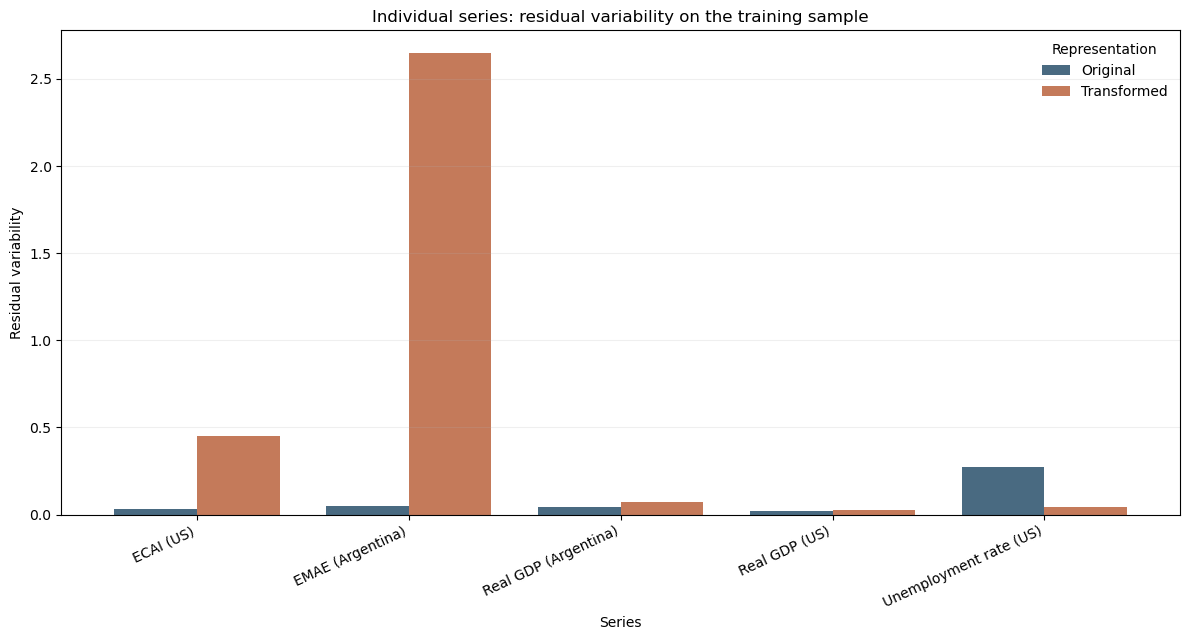

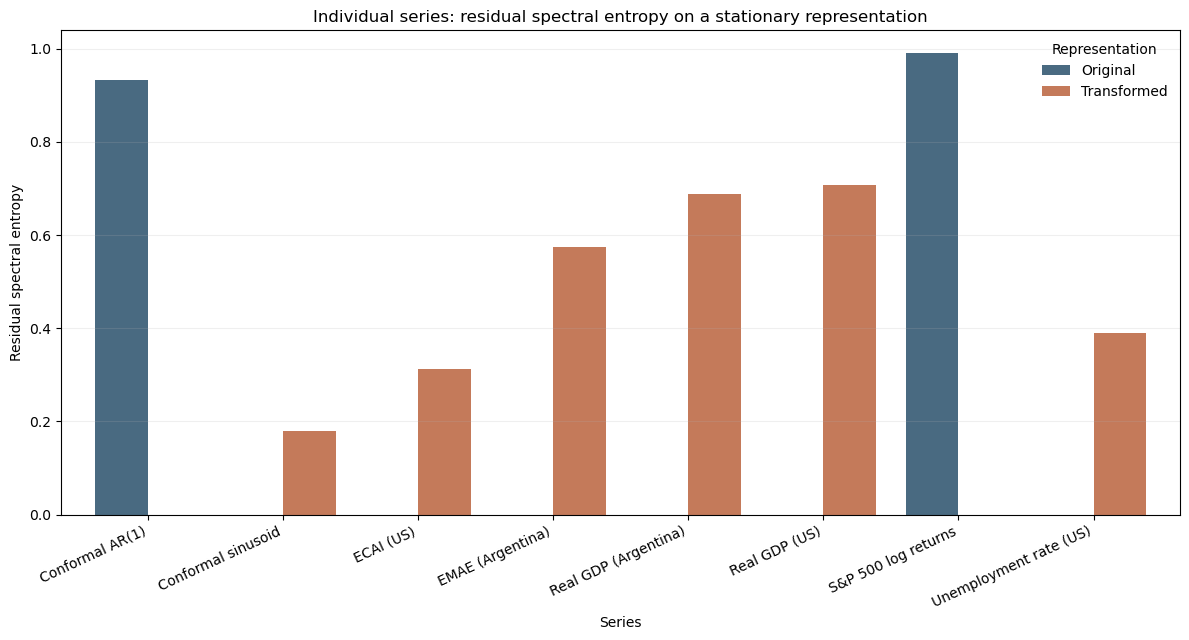

In [6]:
individual_points = forecastability_per_series[
    forecastability_per_series['Scope'].eq('Individual')
].copy()

def plot_individual_metric(data, metric, title, ylabel, filename):
    plot_data = data[data[metric].notna()].copy()
    label_order = list(dict.fromkeys(plot_data['Dataset Label']))
    wide = plot_data.pivot_table(
        index='Dataset Label', columns='Version', values=metric, aggfunc='first'
    ).reindex(label_order)
    version_order = [
        version for version in ('Original', 'Transformed') if version in wide.columns
    ]
    wide = wide[version_order]
    colors = {'Original': '#496a81', 'Transformed': '#c47a5a'}
    fig, axis = plt.subplots(figsize=(12, 6.5))
    wide.plot(
        kind='bar', ax=axis,
        color=[colors[column] for column in wide.columns],
        width=0.78,
    )
    axis.set(title=title, xlabel='Series', ylabel=ylabel)
    axis.tick_params(axis='x', rotation=25)
    for label in axis.get_xticklabels():
        label.set_horizontalalignment('right')
    axis.grid(axis='y', alpha=0.20)
    axis.legend(title='Representation', frameon=False)
    fig.tight_layout()
    save_matplotlib_figure(
        fig, FIGURE_DIR / filename, SAVE_FIGURES, dpi=300
    )
    plt.show()


plot_individual_metric(
    individual_points,
    'RV',
    'Individual series: residual variability on the training sample',
    'Residual variability',
    f'forecastability_individual_rv.{FIGURE_FORMAT}',
)
plot_individual_metric(
    individual_points,
    'RSE',
    'Individual series: residual spectral entropy on a stationary representation',
    'Residual spectral entropy',
    f'forecastability_individual_rse.{FIGURE_FORMAT}',
)

## Global synthetic forecastability plots

Each point is one of the 100 series in a global panel. The box summarizes the process-level distribution, and its mean is displayed. This preserves heterogeneity while the exported headline table reports the corresponding average.

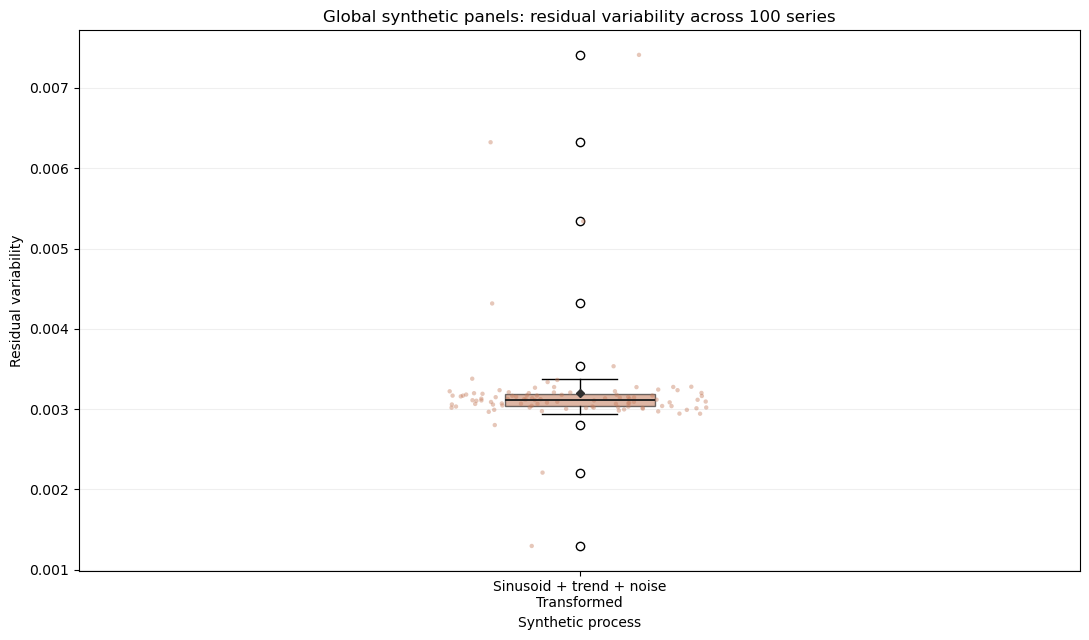

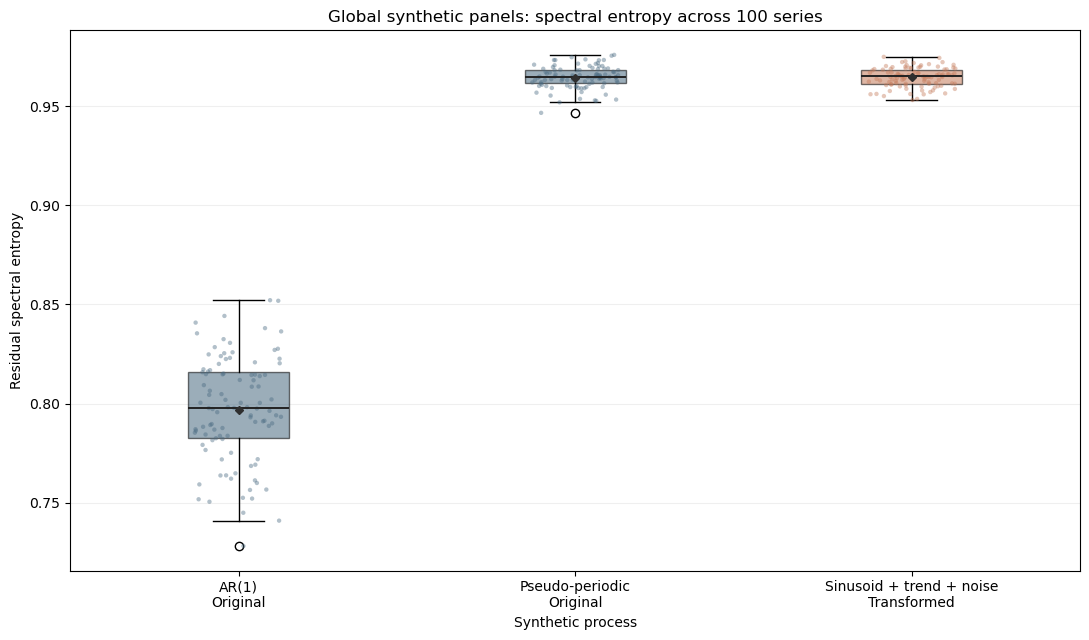

In [7]:
global_points = forecastability_per_series[
    forecastability_per_series['Scope'].eq('Global synthetic')
].copy()

def plot_global_metric(data, metric, title, ylabel, filename):
    plot_data = data[data[metric].notna()].copy()
    groups = []
    labels = []
    colors = []
    color_map = {'Original': '#496a81', 'Transformed': '#c47a5a'}
    for (dataset_label, version), group in plot_data.groupby(
        ['Dataset Label', 'Version'], sort=False
    ):
        groups.append(group[metric].to_numpy(dtype=float))
        labels.append(f'{dataset_label}\n{version}')
        colors.append(color_map.get(version, '#7a7a7a'))

    fig, axis = plt.subplots(figsize=(11, 6.5))
    boxes = axis.boxplot(
        groups,
        tick_labels=labels,
        patch_artist=True,
        showmeans=True,
        meanprops={
            'marker': 'D', 'markerfacecolor': '#2f2f2f',
            'markeredgecolor': '#2f2f2f', 'markersize': 4,
        },
        medianprops={'color': '#222222', 'linewidth': 1.4},
    )
    for patch, color in zip(boxes['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)

    rng = np.random.default_rng(67)
    for position, values in enumerate(groups, start=1):
        jitter = rng.uniform(-0.13, 0.13, len(values))
        axis.scatter(
            position + jitter, values, s=10, alpha=0.42,
            color=colors[position - 1], edgecolors='none', zorder=2,
        )
    axis.set(title=title, xlabel='Synthetic process', ylabel=ylabel)
    axis.grid(axis='y', alpha=0.20)
    fig.tight_layout()
    save_matplotlib_figure(
        fig, FIGURE_DIR / filename, SAVE_FIGURES, dpi=300
    )
    plt.show()


plot_global_metric(
    global_points,
    'RV',
    'Global synthetic panels: residual variability across 100 series',
    'Residual variability',
    f'forecastability_global_rv.{FIGURE_FORMAT}',
)
plot_global_metric(
    global_points,
    'RSE',
    'Global synthetic panels: spectral entropy across 100 series',
    'Residual spectral entropy',
    f'forecastability_global_rse.{FIGURE_FORMAT}',
)

## Interpretation guardrails

- Lower RV indicates less residual variation relative to the original-series level; lower RSE indicates greater spectral concentration and hence more regular frequency-domain structure.
- RV is ill-conditioned when a series mean is close to zero. It is therefore reported as unavailable when the absolute training mean is no more than 10% of the series SD; SD and normalized RSE remain available for the centered AR(1), pseudo-periodic, return, and deterministic-sinusoid targets.
- RV and RSE are descriptive diagnostics, not substitutes for out-of-sample forecast errors.
- Manual-series results are single-series estimates and should not be interpreted as population averages.
- Global means are supported by 100 independently generated component series; the point distributions show how much the diagnostic varies around each mean.
- Already stationary targets are diagnosed directly. AutoStationary rows are retained only where detrending or deseasonalization is part of the declared representation; this includes the deterministic conformal sinusoid. Forecast evaluation remains on the original target scale after inversion.